In [127]:
import pandas as pd

In [128]:
df = pd.read_csv('awards.csv', encoding='latin1')
df

,Name,Baccalaureate Institution,Field of Study,Current Institution
0,"Mayerfeld, Hadassah T",Yeshiva University,Engineering - Biomedical Engineering,Columbia University
1,"Zitzewitz, Zachary",Yale University,Engineering - Optical Engineering,Yale University
2,"Zhao, Lawrence",Yale University,Comp/IS/Eng - Artificial Intelligence,Yale University
3,"Zeitlin, Joshua Darryl",Yale University,"Mathematical Sciences - Algebra, Number Theory...",Cambridge University
4,"Wittemyer, Elena",Yale University,Engineering - Aeronautical and Aerospace Engin...,Stanford University
...,...,...,...,...
2594,"Dai, Kevin Tianjun",Amherst College,Comp/IS/Eng - Machine Learning,Georgia Tech Research Corporation
2595,"Cassata, Bridget",Amherst College,Life Sciences - Microbial Biology,Johns Hopkins University
2596,"Alaoui, Zaki Ellis M",Amherst College,Life Sciences - Neurosciences,NaN
2597,"Mikkelson, Jane A",American University,STEM Education and Learning Research - Technol...,University of California-Irvine


In [129]:
df[df['Baccalaureate Institution'] == 'University of Delaware']

,Name,Baccalaureate Institution,Field of Study,Current Institution
760,"Tarr, Megan Elise",University of Delaware,Engineering - Biomedical Engineering,North Carolina State University
761,"Spangler, Abigail P",University of Delaware,Engineering - Chemical Engineering,Regents of the University of Michigan - Ann Arbor
762,"Smoot, Timothy",University of Delaware,Geosciences - Marine Ecology,UNIVERSITY OF NORTH CAROLINA AT CHAPEL HILL
763,"Shank, Calista",University of Delaware,Psychology - Developmental Psychology,NaN
764,"Mulrooney, Alex Joseph",University of Delaware,Engineering - Machine Learning,University of Delaware
765,"Mahmood, Talha",University of Delaware,Comp/IS/Eng - Artificial Intelligence,University of Delaware
766,"Gallagher, Lindsay Maire",University of Delaware,Engineering - Biomedical Engineering,University of Delaware
767,"Chittakone, Samantha",University of Delaware,Engineering - Environmental and/or Ecological ...,University of Delaware
768,"Chatfield, Ryann J",University of Delaware,Engineering - Biomedical Engineering,University of Delaware
769,"Carmello, Caldonia",University of Delaware,Engineering - Environmental and/or Ecological ...,NaN


In [130]:
chemical_engineering_seniors = df.loc[
    (df['Field of Study'] == 'Engineering - Chemical Engineering')
    & (df['Current Institution'].isna()),
    ['Baccalaureate Institution']
]

baccalaureate_counts = (
    chemical_engineering_seniors
    .value_counts()
    .rename_axis('Baccalaureate Institution')
    .reset_index(name='Number of Awardees')
)
baccalaureate_counts.to_markdown('chemical_engineering_seniors_by_baccalaureate.md', index=False)
baccalaureate_counts


,Baccalaureate Institution,Number of Awardees
0,"UNIVERSITY OF CALIFORNIA, BERKELEY",2
1,Columbia University,1
2,University of South Alabama,1


In [131]:
same_institution = df.loc[
    (df['Field of Study'] == 'Engineering - Chemical Engineering')
    & (df['Current Institution'] == df['Baccalaureate Institution']),
    ['Baccalaureate Institution']
]

same_institution_counts = (
    same_institution
    .value_counts()
    .rename_axis('Baccalaureate Institution')
    .reset_index(name='Number of Awardees')
)
same_institution_counts.to_markdown('chemical_engineering_same_institution_by_baccalaureate.md', index=False)
print(f"total # awardees: {same_institution_counts['Number of Awardees'].sum()}")
same_institution_counts


total # awardees: 45


,Baccalaureate Institution,Number of Awardees
0,UNIVERSITY OF WASHINGTON,3
1,Columbia University,3
2,GEORGIA INSTITUTE OF TECHNOLOGY,3
3,"PENNSYLVANIA STATE UNIVERSITY, THE",2
4,"UNIVERSITY OF CALIFORNIA, BERKELEY",2
5,Stanford University,2
6,University of Texas at Austin,2
7,Regents of the University of Michigan - Ann Arbor,2
8,Johns Hopkins University,2
9,University of Wisconsin-Madison,1


In [132]:
field_award_breakdown = (
    df.assign(
        senior_undergrad=df['Current Institution'].eq(df['Baccalaureate Institution']),
        first_year_grad_students_ish=(
            df['Current Institution'].notna()
            & df['Current Institution'].ne(df['Baccalaureate Institution'])
        ),
    )
    .groupby('Field of Study', dropna=False)
    .agg(
        total_awards=('Name', 'size'),
        senior_undergrads=('senior_undergrad', 'sum'),
        first_year_grad_students_ish=('first_year_grad_students_ish', 'sum'),
    )
    .reset_index()
    .sort_values(['total_awards', 'Field of Study'], ascending=[False, True])
)

field_award_breakdown = field_award_breakdown.rename(columns={
    'Field of Study': 'Field of Study',
    'total_awards': 'Total Awards',
    'senior_undergrads': 'Senior Undergrads',
    'first_year_grad_students_ish': 'First-Year Grad Students-ish',
})
field_award_breakdown.to_markdown('field_of_study_award_breakdown.md', index=False)
field_award_breakdown


,Field of Study,Total Awards,Senior Undergrads,First-Year Grad Students-ish
43,Engineering - Biomedical Engineering,214,111,83
44,Engineering - Chemical Engineering,109,45,60
56,Engineering - Mechanical Engineering,109,55,51
42,Engineering - Bioengineering,108,51,43
105,Life Sciences - Ecology,102,22,43
...,...,...,...,...
173,Social Sciences - Artificial Intelligence,1,0,0
175,Social Sciences - Communications,1,1,0
180,Social Sciences - Law and Social Science,1,0,1
182,Social Sciences - Medical Anthropology,1,0,1


In [133]:
chemical_engineering_first_year_phd_winners = df.loc[
    (df['Field of Study'] == 'Engineering - Chemical Engineering')
    & df['Current Institution'].notna()
    & df['Current Institution'].ne(df['Baccalaureate Institution']),
    ['Current Institution']
]

chemical_engineering_first_year_phd_by_school = (
    chemical_engineering_first_year_phd_winners
    .value_counts()
    .rename_axis('Current Institution')
    .reset_index(name='Number of First-Year PhD Student Winners')
    .sort_values(['Number of First-Year PhD Student Winners', 'Current Institution'], ascending=[False, True])
)
chemical_engineering_first_year_phd_by_school.to_markdown('chemical_engineering_first_year_phd_by_current_institution.md', index=False)
chemical_engineering_first_year_phd_by_school


,Current Institution,Number of First-Year PhD Student Winners
0,Massachusetts Institute of Technology,7
1,Princeton University,6
3,Regents of the University of Michigan - Ann Arbor,5
2,"UNIVERSITY OF CALIFORNIA, BERKELEY",5
5,Stanford University,4
4,University of Delaware,4
6,California Institute of Technology,3
7,University of Texas at Austin,3
9,GEORGIA INSTITUTE OF TECHNOLOGY,2
11,University of California-Berkeley,2


## Publication visualizations

Generate the 600-DPI Okabe–Ito figures used in the Quarto report.

In [134]:
from pathlib import Path
import textwrap

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


DATA_PATH = Path("awards.csv")
FIGURE_DIR = Path("figures")
FIELD = "Engineering - Chemical Engineering"

COLORS = {
    "orange": "#E69F00",
    "sky_blue": "#56B4E9",
    "bluish_green": "#009E73",
    "yellow": "#F0E442",
    "blue": "#0072B2",
    "vermillion": "#D55E00",
    "reddish_purple": "#CC79A7",
    "black": "#000000",
}


def wrap_labels(values, width=34):
    return [textwrap.fill(str(value), width=width) for value in values]


def save_figure(fig, path):
    fig.savefig(
        path,
        dpi=900,
        bbox_inches="tight",
        facecolor="white",
    )


def style_axis(ax, axis="x"):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis=axis, color="#D9E2E8", linewidth=0.7, alpha=0.8)
    ax.set_axisbelow(True)


def field_breakdown(df):
    return (
        df.assign(
            same_institution=df["Current Institution"].eq(
                df["Baccalaureate Institution"]
            ),
            different_institution=(
                df["Current Institution"].notna()
                & df["Current Institution"].ne(df["Baccalaureate Institution"])
            ),
        )
        .groupby("Field of Study", dropna=False)
        .agg(
            total_awards=("Name", "size"),
            same_institution=("same_institution", "sum"),
            different_institution=("different_institution", "sum"),
        )
        .reset_index()
        .sort_values(["total_awards", "Field of Study"], ascending=[False, True])
    )


FIGURE_DIR.mkdir(exist_ok=True)
visualization_field_counts = field_breakdown(df)


### Fields receiving the most awards


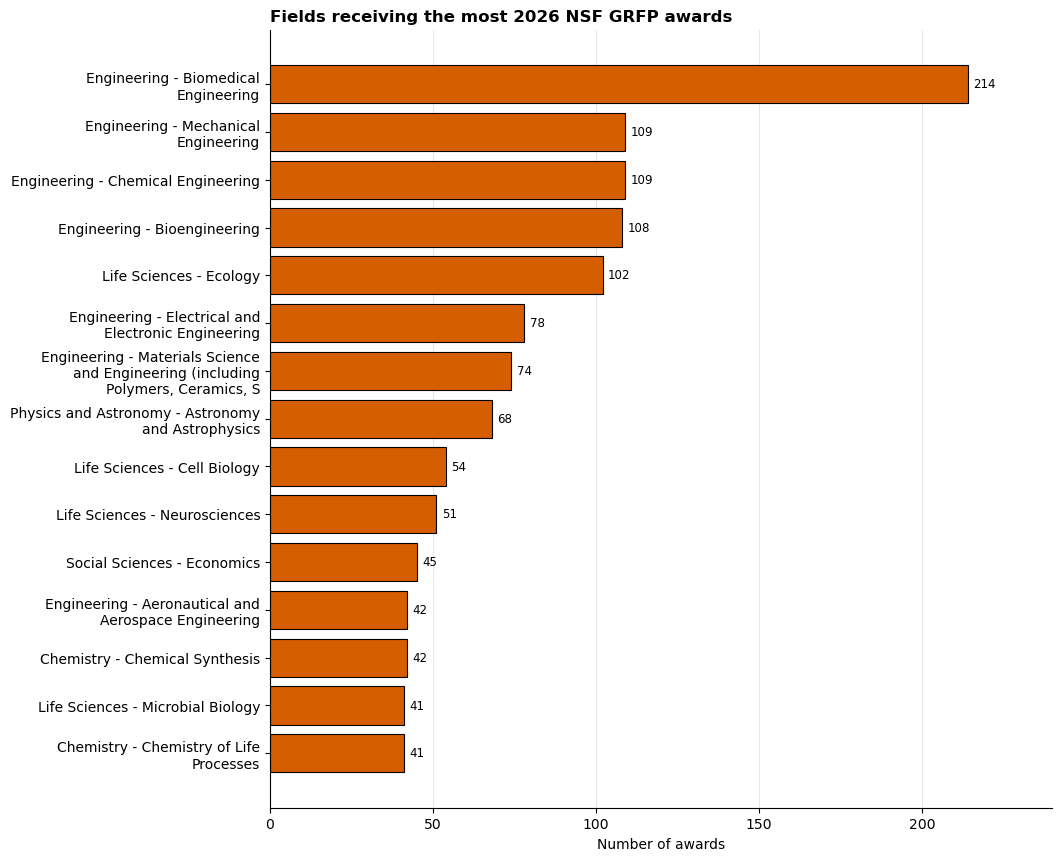

In [135]:
top_fields = visualization_field_counts.head(15).sort_values("total_awards")

fig, ax = plt.subplots(figsize=(10.5, 8.5), layout="constrained")
bars = ax.barh(
    wrap_labels(top_fields["Field of Study"]),
    top_fields["total_awards"],
    color=COLORS["vermillion"],
    edgecolor=COLORS["black"],
    linewidth=0.8,
)
ax.bar_label(bars, padding=4, fontsize=8.5)
ax.set_title(
    "Fields receiving the most 2026 NSF GRFP awards",
    loc="left",
    weight="bold",
)
ax.set_xlabel("Number of awards")
ax.set_ylabel("")
ax.set_xlim(0, top_fields["total_awards"].max() * 1.12)
style_axis(ax)
save_figure(fig, FIGURE_DIR / "top-fields-total-awards.png")
plt.show()
plt.close(fig)


### Institutional pathways among highly awarded fields


In [ ]:
top_pathways = visualization_field_counts.head(12).sort_values("total_awards")
y = np.arange(len(top_pathways))
height = 0.34

fig, ax = plt.subplots(figsize=(10.5, 8.3), layout="constrained")
same = ax.barh(
    y - height / 2,
    top_pathways["same_institution"],
    height,
    label="Senior Undergraduates",
    color=COLORS["orange"],
    edgecolor=COLORS["black"],
    linewidth=0.8,
)
different = ax.barh(
    y + height / 2,
    top_pathways["different_institution"],
    height,
    label="1st year PhD students",
    color=COLORS["sky_blue"],
    edgecolor=COLORS["black"],
    linewidth=0.8,
)
ax.bar_label(same, padding=3, fontsize=8)
ax.bar_label(different, padding=3, fontsize=8)
ax.set_yticks(y, wrap_labels(top_pathways["Field of Study"]))
ax.set_title(
    "The proportion of senior undergraduates is not constant among top-awarded fields",
    loc="left",
    weight="bold",
)
ax.set_xlabel("Number of awards")
ax.set_ylabel("")
ax.legend(frameon=False, loc="lower right")
ax.set_xlim(
    0,
    max(
        top_pathways["same_institution"].max(),
        top_pathways["different_institution"].max(),
    )
    * 1.16,
)
style_axis(ax)
save_figure(fig, FIGURE_DIR / "top-fields-institutional-pathways.png")
plt.show()
plt.close(fig)


### Leading institutions for Chemical Engineering first-year PhD winners


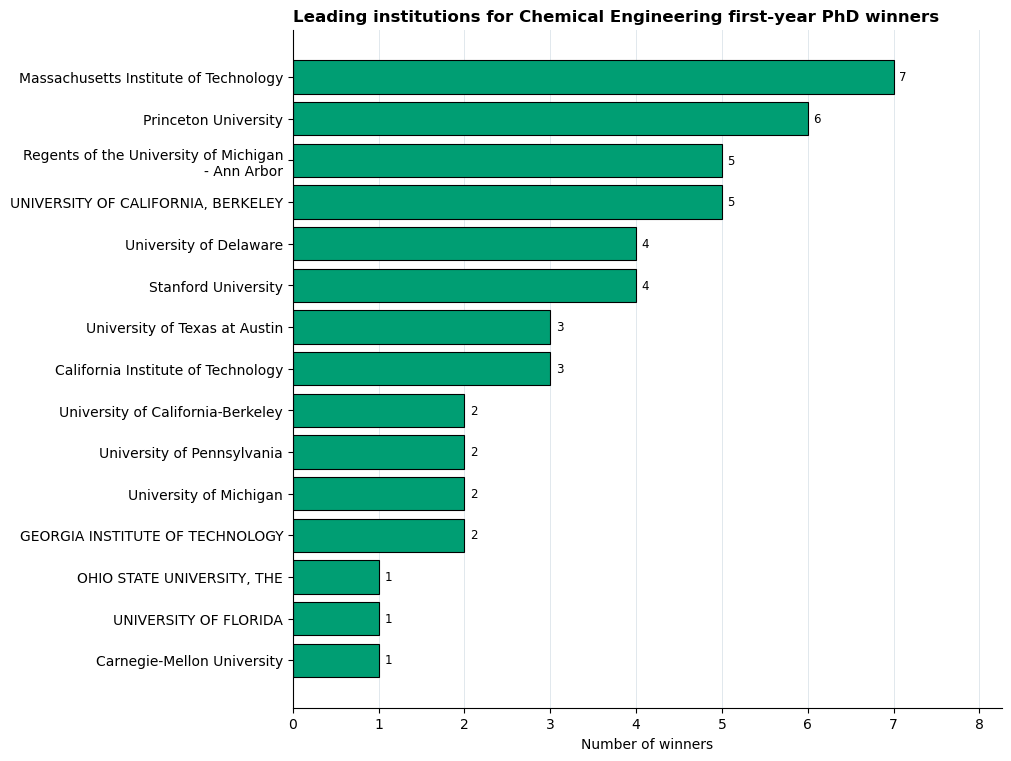

In [ ]:
chemical_engineering_phd_counts = (
    df.loc[
        (df["Field of Study"] == FIELD)
        & df["Current Institution"].notna()
        & df["Current Institution"].ne(df["Baccalaureate Institution"]),
        "Current Institution",
    ]
    .value_counts()
    .head(15)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 7.5), layout="constrained")
bars = ax.barh(
    wrap_labels(chemical_engineering_phd_counts.index, width=38),
    chemical_engineering_phd_counts.values,
    color=COLORS["bluish_green"],
    edgecolor=COLORS["black"],
    linewidth=0.8,
)
ax.bar_label(bars, padding=4, fontsize=8.5)
ax.set_title(
    "Leading institutions for Chemical Engineering first-year PhD winners",
    loc="left",
    weight="bold",
)
ax.set_xlabel("Number of winners")
ax.set_ylabel("")
ax.set_xlim(0, chemical_engineering_phd_counts.max() * 1.18)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
style_axis(ax)
save_figure(
    fig,
    FIGURE_DIR / "chemical-engineering-first-year-phd-institutions.png",
)
plt.show()
plt.close(fig)


## NSF GRFP awards over time


In [ ]:
import re
import unicodedata

YEARLY_DATA_DIR = Path("yearly grfp data")
annual_paths = sorted(YEARLY_DATA_DIR.glob("AwardeeList*.xls"))
required_columns = {
    "Name",
    "Baccalaureate Institution",
    "Field of Study",
    "Current Institution",
}

annual_frames = []
for path in annual_paths:
    annual = pd.read_csv(path, sep="\t", encoding="latin1", dtype=str)
    if set(annual.columns) != required_columns:
        raise ValueError(f"Unexpected columns in {path.name}: {list(annual.columns)}")
    annual["Year"] = int(re.search(r"(\d{4})$", path.stem).group(1))
    annual_frames.append(annual)

yearly_df = pd.concat(annual_frames, ignore_index=True)


def institution_key(value):
    if pd.isna(value):
        return pd.NA
    normalized = (
        unicodedata.normalize("NFKD", str(value))
        .encode("ascii", "ignore")
        .decode()
        .casefold()
        .replace("&", " and ")
    )
    normalized = re.sub(r"[^a-z0-9]+", " ", normalized).strip()
    aliases = {
        "harvard college president and fellows of": "harvard university",
        "regents of the university of michigan ann arbor": "university of michigan ann arbor",
        "university of michigan": "university of michigan ann arbor",
        "william marsh rice university": "rice university",
        "washington university": "washington university in st louis",
    }
    return aliases.get(normalized, normalized)


def preferred_institution_labels(raw_values, keys):
    labels = (
        pd.DataFrame({"raw": raw_values, "key": keys})
        .dropna()
        .groupby("key")["raw"]
        .agg(lambda values: values.value_counts().index[0])
        .to_dict()
    )
    labels.update({
        "harvard university": "Harvard University",
        "rice university": "Rice University",
        "university of california berkeley": "University of California, Berkeley",
        "university of california los angeles": "University of California, Los Angeles",
        "university of michigan ann arbor": "University of Michigan–Ann Arbor",
        "washington university in st louis": "Washington University in St. Louis",
    })
    return labels


yearly_df["Baccalaureate Institution Key"] = yearly_df[
    "Baccalaureate Institution"
].map(institution_key)
yearly_df["Current Institution Key"] = yearly_df[
    "Current Institution"
].map(institution_key)

same_institution = (
    yearly_df["Current Institution Key"].notna()
    & yearly_df["Current Institution Key"].fillna("").eq(
        yearly_df["Baccalaureate Institution Key"].fillna("")
    )
)
different_institution = (
    yearly_df["Current Institution Key"].notna()
    & ~same_institution
)
yearly_df["Inferred career stage"] = np.select(
    [same_institution, different_institution],
    ["Senior-undergraduate proxy", "Graduate-student proxy"],
    default="Current institution not listed",
)
yearly_df["Broad field"] = (
    yearly_df["Field of Study"].str.split(" - ", n=1).str[0].str.strip()
)

current_labels = preferred_institution_labels(
    yearly_df["Current Institution"], yearly_df["Current Institution Key"]
)
baccalaureate_labels = preferred_institution_labels(
    yearly_df["Baccalaureate Institution"],
    yearly_df["Baccalaureate Institution Key"],
)
years = sorted(yearly_df["Year"].unique())

if len(annual_paths) != 17 or years != list(range(2010, 2027)):
    raise ValueError("Expected one award file for every year from 2010 through 2026.")


## Awards given each year


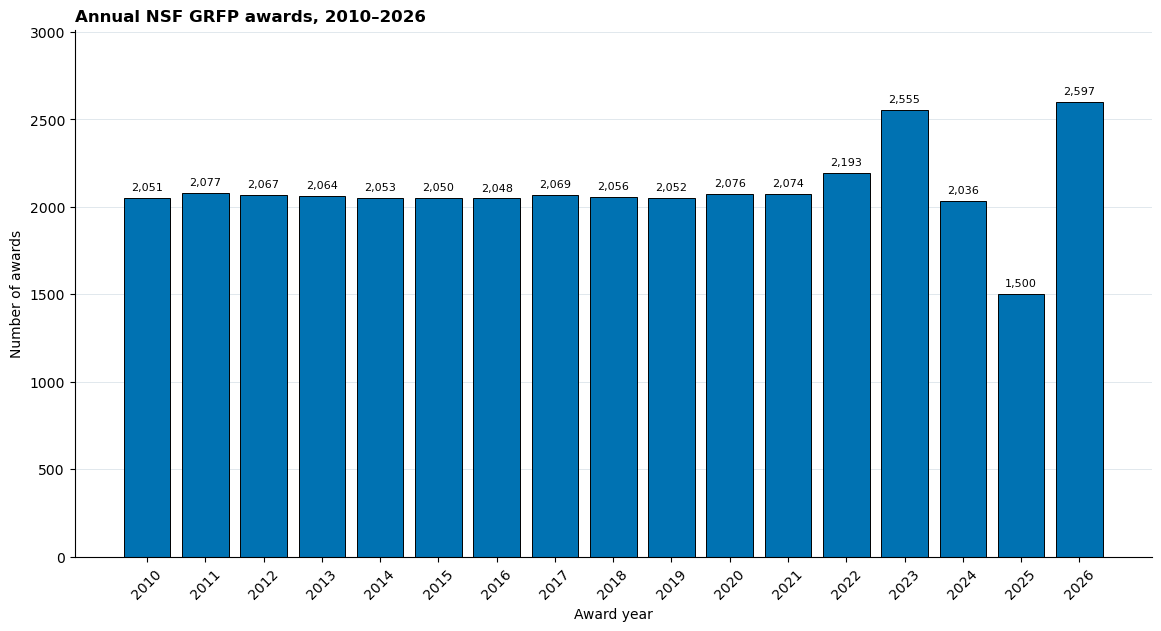

In [ ]:
annual_counts = yearly_df.groupby("Year").size().reindex(years)

fig, ax = plt.subplots(figsize=(11.5, 6.2), layout="constrained")
bars = ax.bar(
    annual_counts.index,
    annual_counts.values,
    color=COLORS["blue"],
    edgecolor=COLORS["black"],
    linewidth=0.7,
)
ax.bar_label(bars, labels=[f"{value:,}" for value in annual_counts], padding=4, fontsize=8)
ax.set_title("Annual NSF GRFP awards, 2010–2026", loc="left", weight="bold")
ax.set_xlabel("Award year")
ax.set_ylabel("Number of awards")
ax.set_xticks(years)
ax.tick_params(axis="x", rotation=45)
ax.set_ylim(0, annual_counts.max() * 1.16)
style_axis(ax, axis="y")
save_figure(fig, FIGURE_DIR / "annual-award-counts.png")
plt.show()
plt.close(fig)


## Awards by inferred career stage


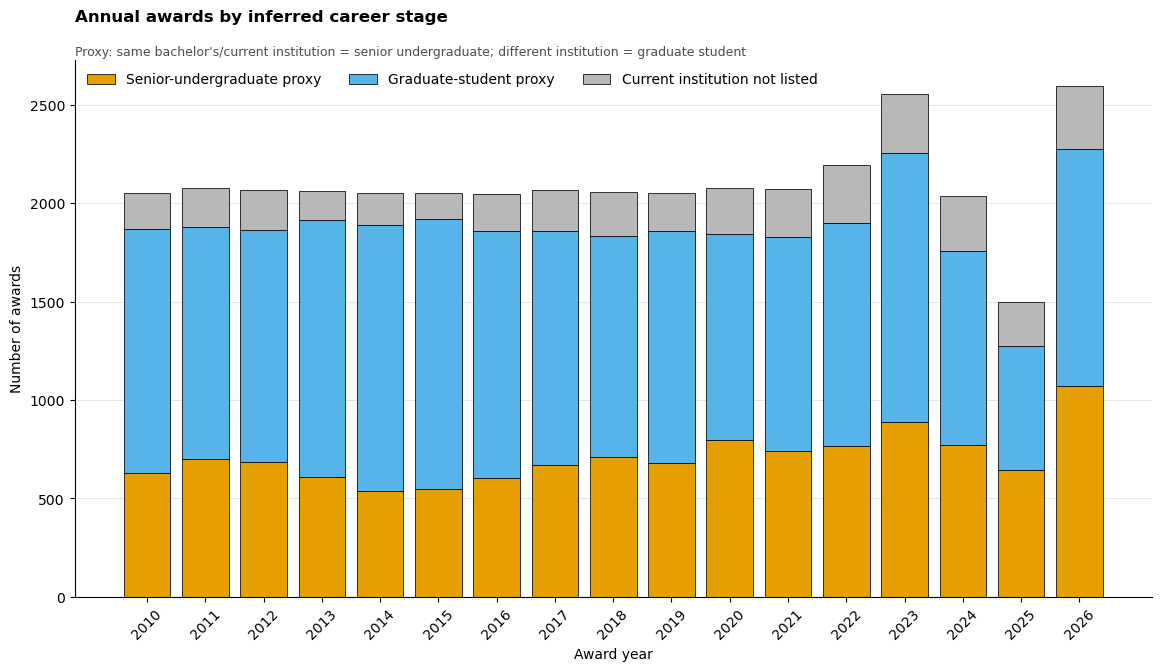

In [ ]:
stage_order = [
    "Senior-undergraduate proxy",
    "Graduate-student proxy",
    "Current institution not listed",
]
stage_counts = (
    pd.crosstab(yearly_df["Year"], yearly_df["Inferred career stage"])
    .reindex(index=years, columns=stage_order, fill_value=0)
)

fig, ax = plt.subplots(figsize=(11.5, 6.6), layout="constrained")
bottom = np.zeros(len(stage_counts))
stage_colors = [COLORS["orange"], COLORS["sky_blue"], "#B8B8B8"]
for stage, color in zip(stage_order, stage_colors):
    ax.bar(
        stage_counts.index,
        stage_counts[stage],
        bottom=bottom,
        label=stage,
        color=color,
        edgecolor=COLORS["black"],
        linewidth=0.55,
    )
    bottom += stage_counts[stage].to_numpy()
ax.set_title("Annual awards by inferred career stage", loc="left", weight="bold", pad=28)
ax.text(
    0,
    1.01,
    "Proxy: same bachelor's/current institution = senior undergraduate; different institution = graduate student",
    transform=ax.transAxes,
    fontsize=9,
    color="#4D4D4D",
)
ax.set_xlabel("Award year")
ax.set_ylabel("Number of awards")
ax.set_xticks(years)
ax.tick_params(axis="x", rotation=45)
ax.legend(frameon=False, ncol=3, loc="upper left")
style_axis(ax, axis="y")
save_figure(fig, FIGURE_DIR / "annual-awards-by-inferred-stage.png")
plt.show()
plt.close(fig)


## Career-stage trend among classified awardees


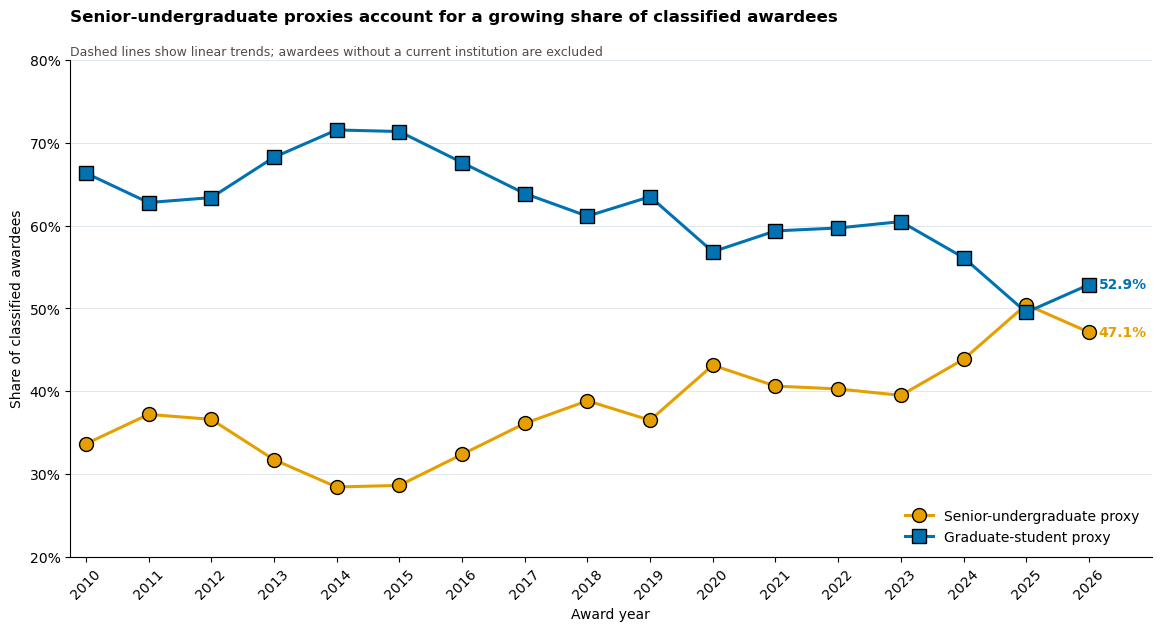

In [ ]:
classified_counts = stage_counts[[
    "Senior-undergraduate proxy",
    "Graduate-student proxy",
]]
stage_shares = classified_counts.div(classified_counts.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11.5, 6.2), layout="constrained")
for stage, color, marker in [
    ("Senior-undergraduate proxy", COLORS["orange"], "o"),
    ("Graduate-student proxy", COLORS["blue"], "s"),
]:
    values = stage_shares[stage]
    ax.plot(years, values, marker=marker, linewidth=2.2, color=color, 
            label=stage, markersize=10, markeredgecolor='black')
    ax.annotate(
        f"{values.iloc[-1]:.1f}%",
        (years[-1], values.iloc[-1]),
        xytext=(7, 0),
        textcoords="offset points",
        va="center",
        color=color,
        weight="bold",
    )
ax.set_title("Senior-undergraduate proxies account for a growing share of classified awardees", loc="left", weight="bold", pad=28)
ax.text(
    0,
    1.01,
    "Dashed lines show linear trends; awardees without a current institution are excluded",
    transform=ax.transAxes,
    fontsize=9,
    color="#4D4D4D",
)
ax.set_xlabel("Award year")
ax.set_ylabel("Share of classified awardees")
ax.set_xticks(years)
ax.tick_params(axis="x", rotation=45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0f}%"))
ax.set_xlim(years[0] - 0.25, years[-1] + 1.0)
ax.set_ylim(20, 80)
ax.legend(frameon=False, loc="lower right")
style_axis(ax, axis="y")
save_figure(fig, FIGURE_DIR / "inferred-career-stage-share.png")
plt.show()
plt.close(fig)


## Leading graduate-school destinations


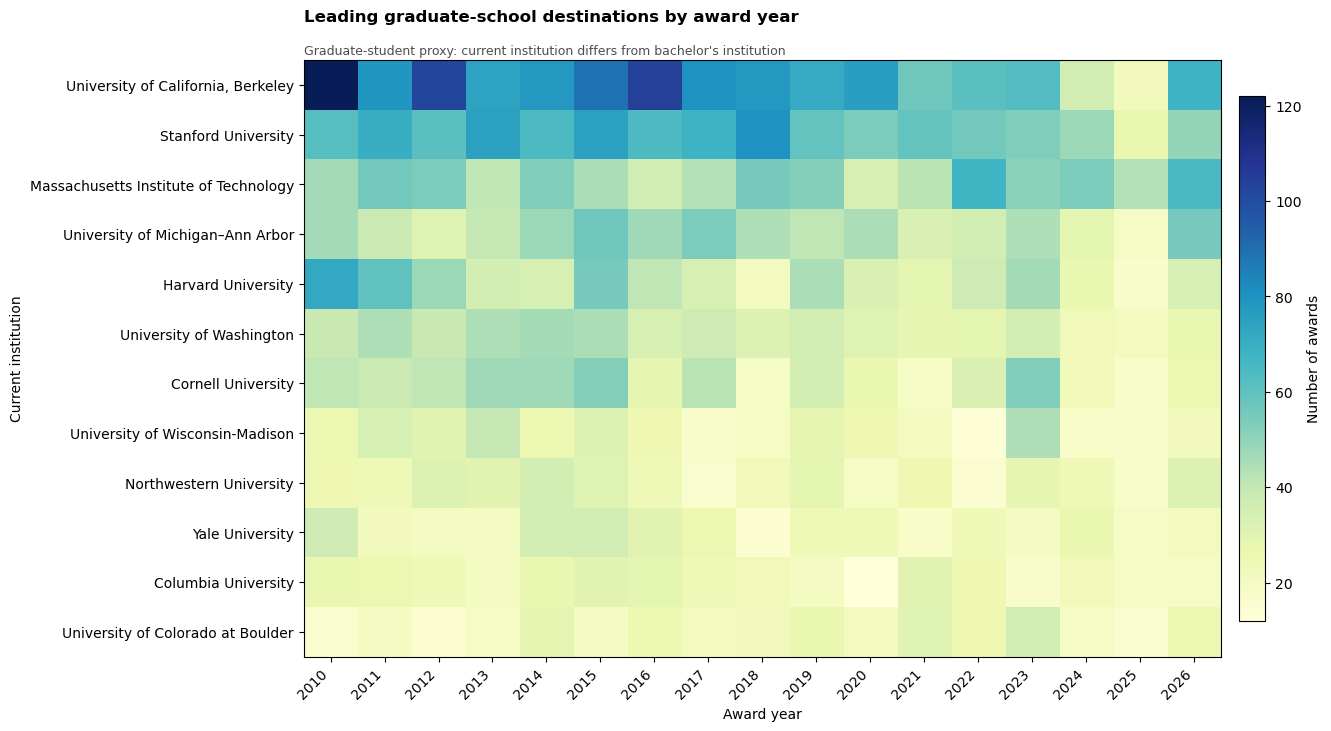

In [ ]:
graduate_destinations = yearly_df.loc[
    yearly_df["Inferred career stage"].eq("Graduate-student proxy")
]
top_destination_keys = (
    graduate_destinations["Current Institution Key"].value_counts().head(12).index
)
destination_grid = (
    graduate_destinations.loc[
        graduate_destinations["Current Institution Key"].isin(top_destination_keys)
    ]
    .groupby(["Current Institution Key", "Year"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=top_destination_keys, columns=years, fill_value=0)
)

fig, ax = plt.subplots(figsize=(13.2, 7.2), layout="constrained")
image = ax.imshow(destination_grid, aspect="auto", cmap="YlGnBu")
ax.set_yticks(
    range(len(destination_grid)),
    [current_labels[key] for key in destination_grid.index],
)
ax.set_xticks(range(len(years)), years, rotation=45, ha="right")
ax.set_title("Leading graduate-school destinations by award year", loc="left", weight="bold", pad=28)
ax.text(
    0,
    1.01,
    "Graduate-student proxy: current institution differs from bachelor's institution",
    transform=ax.transAxes,
    fontsize=9,
    color="#4D4D4D",
)
ax.set_xlabel("Award year")
ax.set_ylabel("Current institution")
colorbar = fig.colorbar(image, ax=ax, shrink=0.88, pad=0.02)
colorbar.set_label("Number of awards")
save_figure(fig, FIGURE_DIR / "graduate-destination-heatmap.png")
plt.show()
plt.close(fig)


## Concentration at current institutions


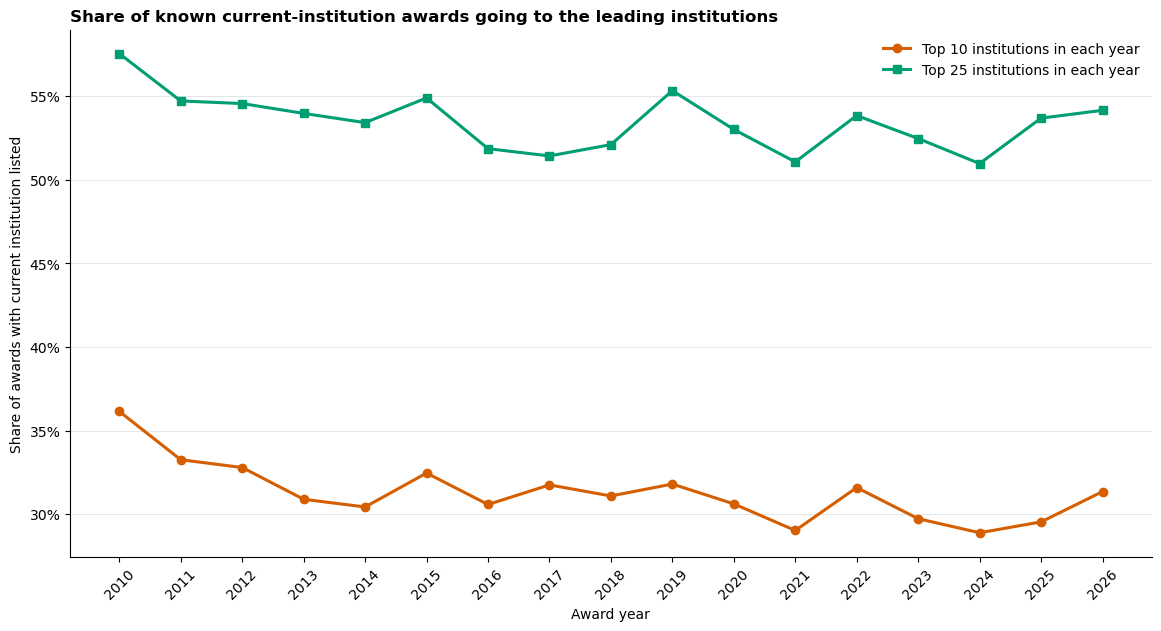

In [ ]:
known_current = yearly_df.dropna(subset=["Current Institution Key"])
institution_year_counts = (
    known_current.groupby(["Year", "Current Institution Key"]).size()
)
concentration = pd.DataFrame(index=years)
for top_n in [10, 25]:
    concentration[f"Top {top_n}"] = [
        institution_year_counts.loc[year].nlargest(top_n).sum()
        / institution_year_counts.loc[year].sum()
        * 100
        for year in years
    ]

fig, ax = plt.subplots(figsize=(11.5, 6.2), layout="constrained")
for column, color, marker in [
    ("Top 10", COLORS["vermillion"], "o"),
    ("Top 25", COLORS["bluish_green"], "s"),
]:
    ax.plot(
        concentration.index,
        concentration[column],
        color=color,
        marker=marker,
        linewidth=2.2,
        label=f"{column} institutions in each year",
    )
ax.set_title("Share of known current-institution awards going to the leading institutions", loc="left", weight="bold")
ax.set_xlabel("Award year")
ax.set_ylabel("Share of awards with current institution listed")
ax.set_xticks(years)
ax.tick_params(axis="x", rotation=45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0f}%"))
ax.legend(frameon=False, loc="best")
style_axis(ax, axis="y")
save_figure(fig, FIGURE_DIR / "current-institution-concentration.png")
plt.show()
plt.close(fig)


## Leading baccalaureate institutions


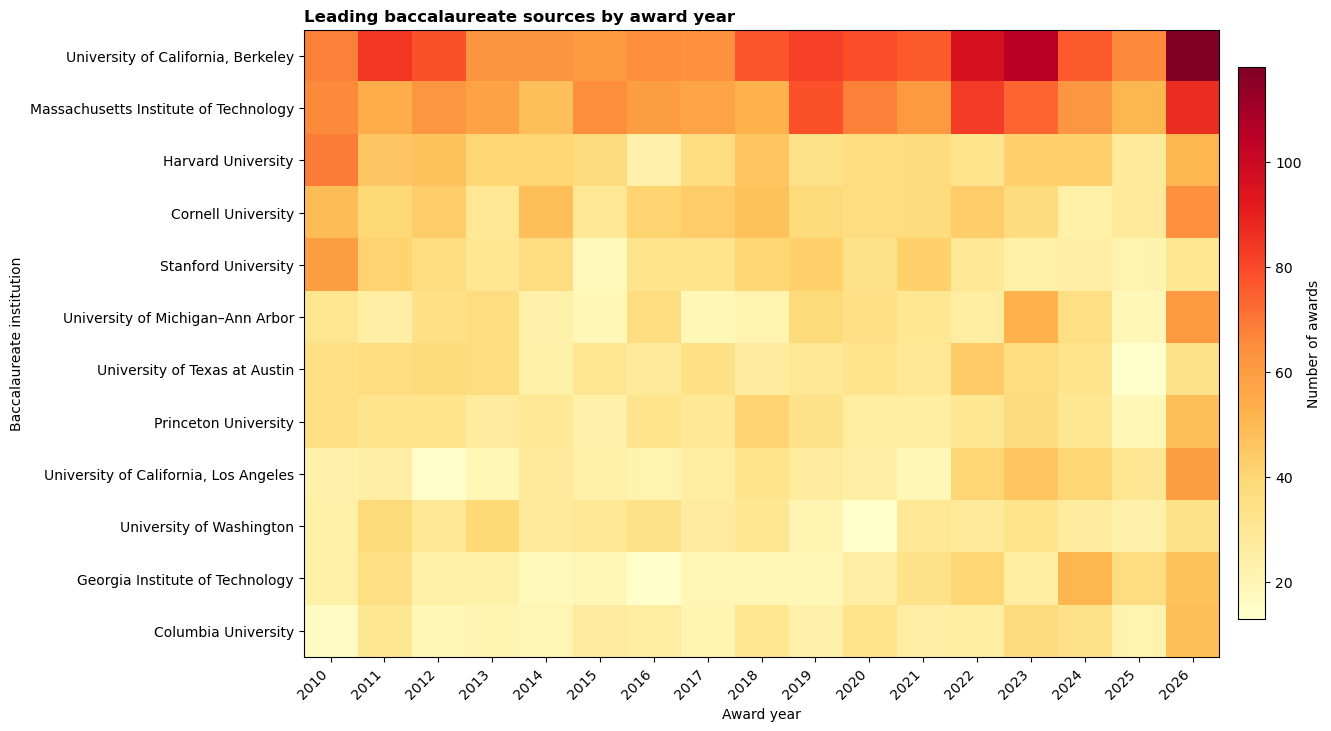

In [ ]:
top_baccalaureate_keys = (
    yearly_df["Baccalaureate Institution Key"].value_counts().head(12).index
)
baccalaureate_grid = (
    yearly_df.loc[
        yearly_df["Baccalaureate Institution Key"].isin(top_baccalaureate_keys)
    ]
    .groupby(["Baccalaureate Institution Key", "Year"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=top_baccalaureate_keys, columns=years, fill_value=0)
)

fig, ax = plt.subplots(figsize=(13.2, 7.2), layout="constrained")
image = ax.imshow(baccalaureate_grid, aspect="auto", cmap="YlOrRd")
ax.set_yticks(
    range(len(baccalaureate_grid)),
    [baccalaureate_labels[key] for key in baccalaureate_grid.index],
)
ax.set_xticks(range(len(years)), years, rotation=45, ha="right")
ax.set_title("Leading baccalaureate sources by award year", loc="left", weight="bold")
ax.set_xlabel("Award year")
ax.set_ylabel("Baccalaureate institution")
colorbar = fig.colorbar(image, ax=ax, shrink=0.88, pad=0.02)
colorbar.set_label("Number of awards")
save_figure(fig, FIGURE_DIR / "baccalaureate-source-heatmap.png")
plt.show()
plt.close(fig)


## Broad-field mix over time


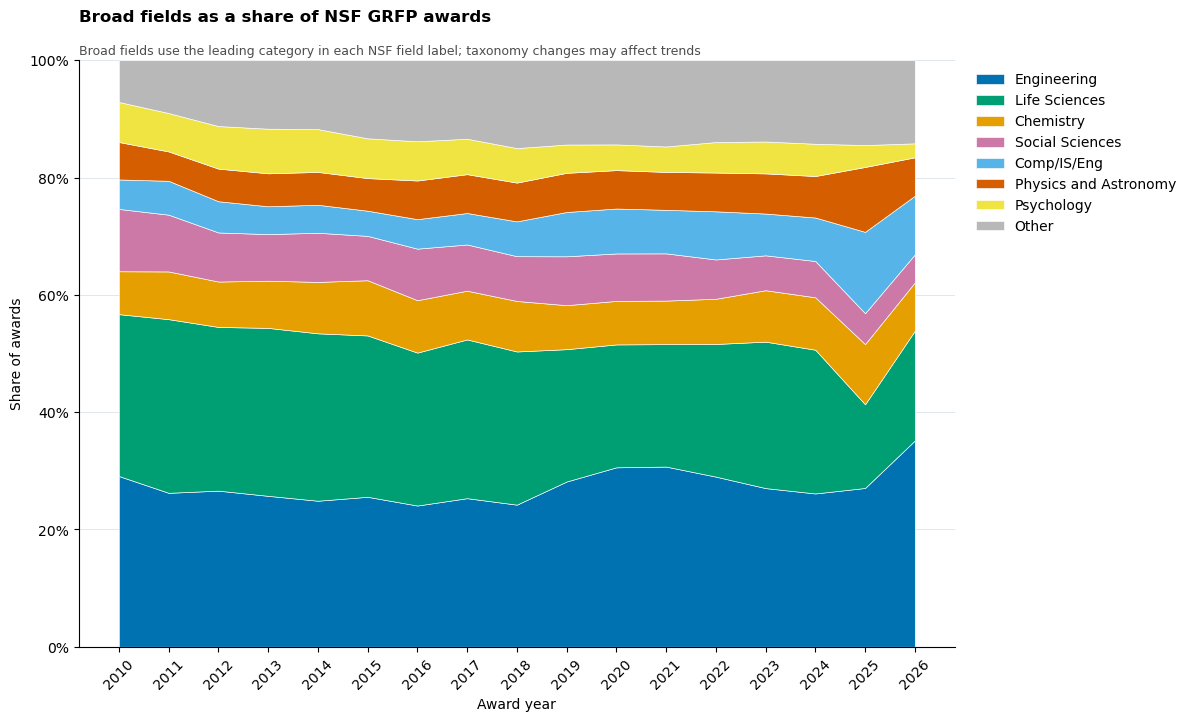

In [ ]:
leading_fields = yearly_df["Broad field"].value_counts().head(7).index.tolist()
field_plot_data = yearly_df.assign(
    Plot_field=yearly_df["Broad field"].where(
        yearly_df["Broad field"].isin(leading_fields), "Other"
    )
)
field_shares = (
    pd.crosstab(field_plot_data["Year"], field_plot_data["Plot_field"])
    .reindex(index=years, columns=leading_fields + ["Other"], fill_value=0)
)
field_shares = field_shares.div(field_shares.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11.8, 7.1), layout="constrained")
field_colors = [
    COLORS["blue"],
    COLORS["bluish_green"],
    COLORS["orange"],
    COLORS["reddish_purple"],
    COLORS["sky_blue"],
    COLORS["vermillion"],
    COLORS["yellow"],
    "#B8B8B8",
]
ax.stackplot(
    years,
    [field_shares[column] for column in field_shares.columns],
    labels=field_shares.columns,
    colors=field_colors,
    edgecolor="white",
    linewidth=0.45,
)
ax.set_title("Broad fields as a share of NSF GRFP awards", loc="left", weight="bold", pad=28)
ax.text(
    0,
    1.01,
    "Broad fields use the leading category in each NSF field label; taxonomy changes may affect trends",
    transform=ax.transAxes,
    fontsize=9,
    color="#4D4D4D",
)
ax.set_xlabel("Award year")
ax.set_ylabel("Share of awards")
ax.set_xticks(years)
ax.tick_params(axis="x", rotation=45)
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0f}%"))
ax.legend(frameon=False, bbox_to_anchor=(1.01, 1), loc="upper left")
style_axis(ax, axis="y")
save_figure(fig, FIGURE_DIR / "broad-field-share-over-time.png")
plt.show()
plt.close(fig)

## Engineering topics over time


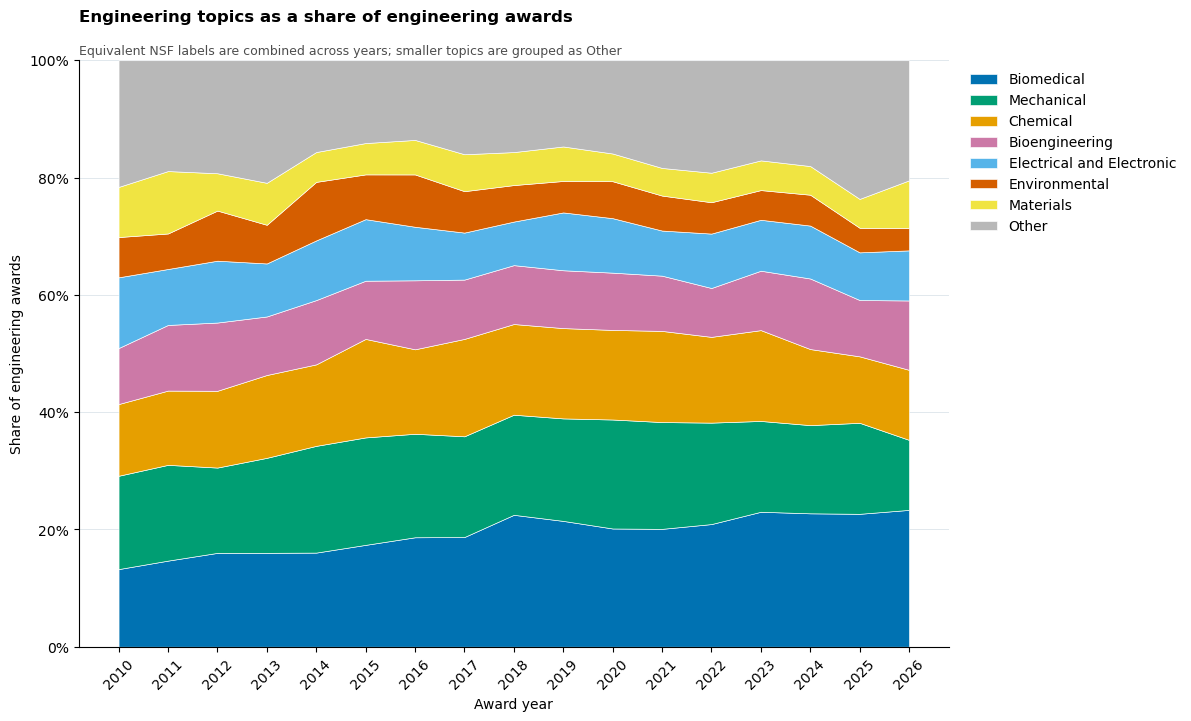

In [ ]:
def normalized_engineering_topic(field):
    topic = field.split(" - ", 1)[1].strip()
    topic_aliases = [
        (r"^Aeronautical and Aerospace", "Aeronautical and Aerospace"),
        (r"^Biomedical", "Biomedical"),
        (r"^Chemical Engineering$", "Chemical"),
        (r"^Civil Engineering", "Civil"),
        (r"^Electrical and Electronic", "Electrical and Electronic"),
        (r"^Energy", "Energy"),
        (r"^Environmental", "Environmental"),
        (r"^Industrial(?: Engineering and Operations Research)?$", "Industrial and Operations Research"),
        (r"^Materials(?: Science and Engineering.*| Engineering)?$", "Materials"),
        (r"^Mechanical(?: Engineering)?$", "Mechanical"),
        (r"^Nuclear(?: Engineering)?$", "Nuclear"),
        (r"^Ocean(?: Engineering)?$", "Ocean"),
    ]
    for pattern, replacement in topic_aliases:
        if re.match(pattern, topic):
            return replacement
    return topic


engineering_awards = yearly_df.loc[
    yearly_df["Broad field"].eq("Engineering")
].copy()
engineering_awards["Engineering topic"] = engineering_awards[
    "Field of Study"
].map(normalized_engineering_topic)
leading_engineering_topics = (
    engineering_awards["Engineering topic"].value_counts().head(7).index.tolist()
)
engineering_plot_data = engineering_awards.assign(
    Plot_topic=engineering_awards["Engineering topic"].where(
        engineering_awards["Engineering topic"].isin(leading_engineering_topics),
        "Other",
    )
)
engineering_topic_shares = (
    pd.crosstab(
        engineering_plot_data["Year"],
        engineering_plot_data["Plot_topic"],
    )
    .reindex(
        index=years,
        columns=leading_engineering_topics + ["Other"],
        fill_value=0,
    )
)
engineering_topic_shares = engineering_topic_shares.div(
    engineering_topic_shares.sum(axis=1), axis=0
) * 100

fig, ax = plt.subplots(figsize=(11.8, 7.1), layout="constrained")
engineering_colors = [
    COLORS["blue"],
    COLORS["bluish_green"],
    COLORS["orange"],
    COLORS["reddish_purple"],
    COLORS["sky_blue"],
    COLORS["vermillion"],
    COLORS["yellow"],
    "#B8B8B8",
]
ax.stackplot(
    years,
    [engineering_topic_shares[column] for column in engineering_topic_shares.columns],
    labels=engineering_topic_shares.columns,
    colors=engineering_colors,
    edgecolor="white",
    linewidth=0.45,
)
ax.set_title(
    "Engineering topics as a share of engineering awards",
    loc="left",
    weight="bold",
    pad=28,
)
ax.text(
    0,
    1.01,
    "Equivalent NSF labels are combined across years; smaller topics are grouped as Other",
    transform=ax.transAxes,
    fontsize=9,
    color="#4D4D4D",
)
ax.set_xlabel("Award year")
ax.set_ylabel("Share of engineering awards")
ax.set_xticks(years)
ax.tick_params(axis="x", rotation=45)
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0f}%"))
ax.legend(frameon=False, bbox_to_anchor=(1.01, 1), loc="upper left")
style_axis(ax, axis="y")
save_figure(fig, FIGURE_DIR / "engineering-topic-share-over-time.png")
plt.show()
plt.close(fig)


## Leading engineering topics over time


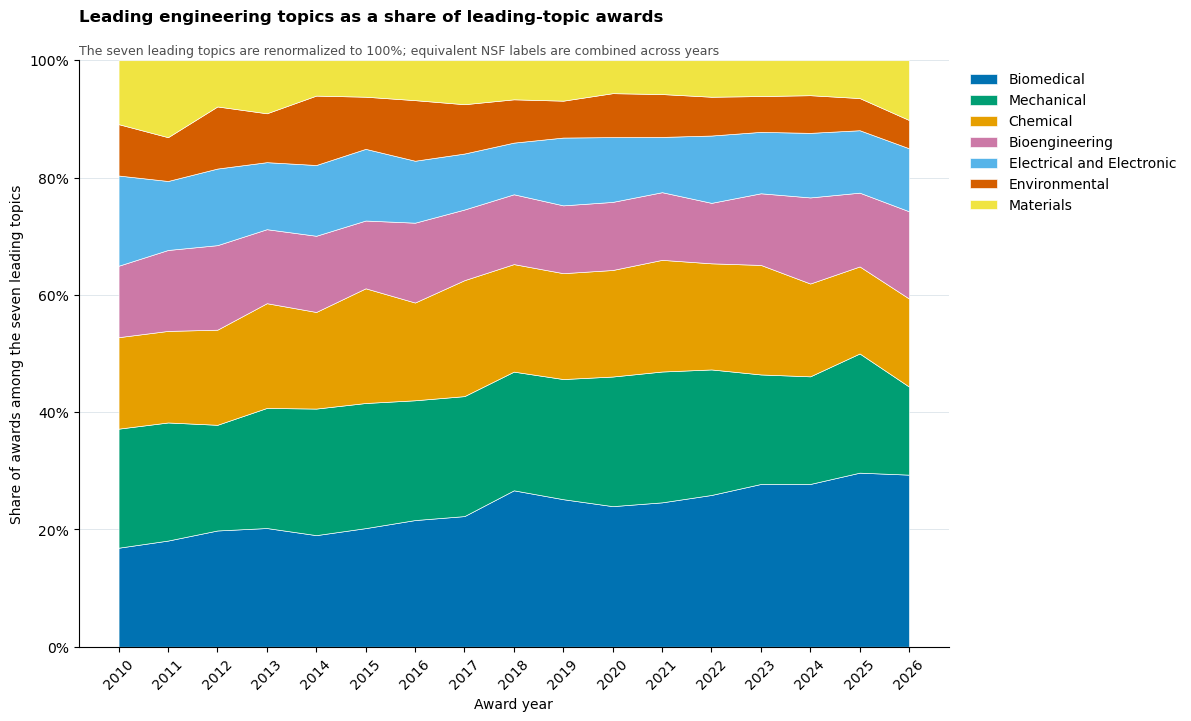

In [ ]:
leading_engineering_topic_shares = engineering_topic_shares[
    leading_engineering_topics
].copy()
leading_engineering_topic_shares = leading_engineering_topic_shares.div(
    leading_engineering_topic_shares.sum(axis=1), axis=0
) * 100

fig, ax = plt.subplots(figsize=(11.8, 7.1), layout="constrained")
ax.stackplot(
    years,
    [
        leading_engineering_topic_shares[column]
        for column in leading_engineering_topic_shares.columns
    ],
    labels=leading_engineering_topic_shares.columns,
    colors=engineering_colors[:len(leading_engineering_topics)],
    edgecolor="white",
    linewidth=0.45,
)
ax.set_title(
    "Leading engineering topics as a share of leading-topic awards",
    loc="left",
    weight="bold",
    pad=28,
)
ax.text(
    0,
    1.01,
    "The seven leading topics are renormalized to 100%; equivalent NSF labels are combined across years",
    transform=ax.transAxes,
    fontsize=9,
    color="#4D4D4D",
)
ax.set_xlabel("Award year")
ax.set_ylabel("Share of awards among the seven leading topics")
ax.set_xticks(years)
ax.tick_params(axis="x", rotation=45)
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0f}%"))
ax.legend(frameon=False, bbox_to_anchor=(1.01, 1), loc="upper left")
style_axis(ax, axis="y")
save_figure(
    fig,
    FIGURE_DIR / "leading-engineering-topic-share-over-time.png",
)
plt.show()
plt.close(fig)


## Mechanical, Chemical, and Biomedical Engineering awards


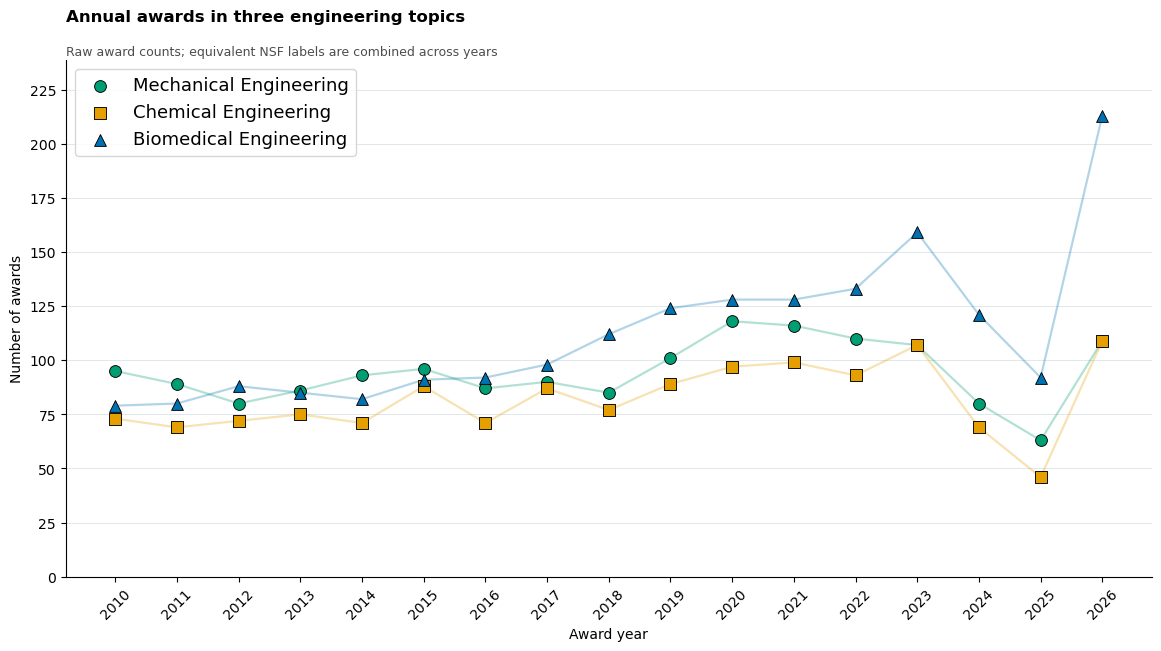

In [191]:
selected_topics = ["Mechanical", "Chemical", "Biomedical"]
selected_topic_counts = (
    engineering_awards.loc[
        engineering_awards["Engineering topic"].isin(selected_topics)
    ]
    .groupby(["Year", "Engineering topic"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=years, columns=selected_topics, fill_value=0)
)

fig, ax = plt.subplots(figsize=(11.5, 6.4), layout="constrained")
for topic, color, marker in [
    ("Mechanical", COLORS["bluish_green"], "o"),
    ("Chemical", COLORS["orange"], "s"),
    ("Biomedical", COLORS["blue"], "^"),
]:
    ax.plot(
        selected_topic_counts.index,
        selected_topic_counts[topic],
        color=color,
        linewidth=1.6,
        alpha=0.3,
        zorder=2,
    )
    ax.scatter(
        selected_topic_counts.index,
        selected_topic_counts[topic],
        s=72,
        color=color,
        marker=marker,
        edgecolor=COLORS["black"],
        linewidth=0.65,
        label=f"{topic} Engineering",
        zorder=3,
    )
ax.set_title(
    "Annual awards in three engineering topics",
    loc="left",
    weight="bold",
    pad=28,
)
ax.text(
    0,
    1.01,
    "Raw award counts; equivalent NSF labels are combined across years",
    transform=ax.transAxes,
    fontsize=9,
    color="#4D4D4D",
)
ax.set_xlabel("Award year")
ax.set_ylabel("Number of awards")
ax.set_xticks(years)
ax.tick_params(axis="x", rotation=45)
ax.set_ylim(0, selected_topic_counts.to_numpy().max() * 1.12)
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.legend(frameon=True, fontsize=13, loc="upper left")
style_axis(ax, axis="y")
save_figure(
    fig,
    FIGURE_DIR / "selected-engineering-topic-award-counts.png",
)
plt.show()
plt.close(fig)
